# Lecture 2: Choose a chart, then communicate the answer

You are preparing charts for the brand's marketing meeting. Use the same data from Lecture 1 to answer six business questions.

For each chart type, start with the question, prepare a new dataframe, and draw a raw plot for data exploration. Then use a polished plot to highlight the answer. Both plots use the same data.

The code is provided. Run the cells in order and compare what changes between the raw and polished versions.

## 0) Setup and data

Keep this notebook and `lecture2.csv` in the same folder. Select your Python kernel in VS Code and run the cells from top to bottom.

We use pandas and Matplotlib as in Lecture 1, plus NumPy to fit the scatterplot's trend line. If a package is missing, uncomment the installation line below and run it once.

In [1]:
# %pip install pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

### Load the data

`lecture2.csv` is a copy of Lecture 1's synthetic dataset for a fictional brand. Each row records one channel on one day. The data contain 448 rows covering September 1 through December 21, 2025: 112 days across four channels.

| Column | Meaning |
| --- | --- |
| `date` | The day of the observation. |
| `week` | Week number, 1–16. |
| `channel` | Email, Organic, Paid Social, or Paid Search. |
| `revenue` | Sales revenue for that channel and day, in currency units. |
| `margin` | Recorded margin amount, in the same currency units. |
| `promo` | 1 on a promotion day, 0 otherwise. |

There are 14 promotion days and 98 days without promotions. Use average daily revenue to compare the two groups. For the line chart, define a month as four consecutive weeks. The 16 weeks form four equal months of 28 days each.

In [2]:
df = pd.read_csv("lecture2.csv", parse_dates=["date"])
df.head()

,date,week,channel,revenue,margin,promo
0,2025-09-01,1,Paid Search,6410.286736,2634.167486,0
1,2025-09-01,1,Paid Social,520.896521,192.911846,0
2,2025-09-01,1,Email,5660.581734,2771.559634,0
3,2025-09-01,1,Organic,1508.135795,683.947402,0
4,2025-09-02,1,Paid Search,3590.394169,1619.710263,0


## 1) Bar chart

**Question:** Which channel generates the highest average daily sales revenue?

### Data preparation

Create `bar_df` with one row per channel. Use `mean` to calculate average daily revenue, then sort the channels from highest to lowest.

In [3]:
bar_df = (
    df.groupby("channel", as_index=False)
      .agg(revenue=("revenue", "mean"))
)

bar_df = bar_df.sort_values("revenue", ascending=False)
bar_df.head()

,channel,revenue
0,Email,7594.863928
2,Paid Search,5786.063643
1,Organic,3642.534124
3,Paid Social,1467.298455


### Raw plot: data exploration

Compare the bar lengths and check the ranking. Both versions show the channels from highest to lowest.

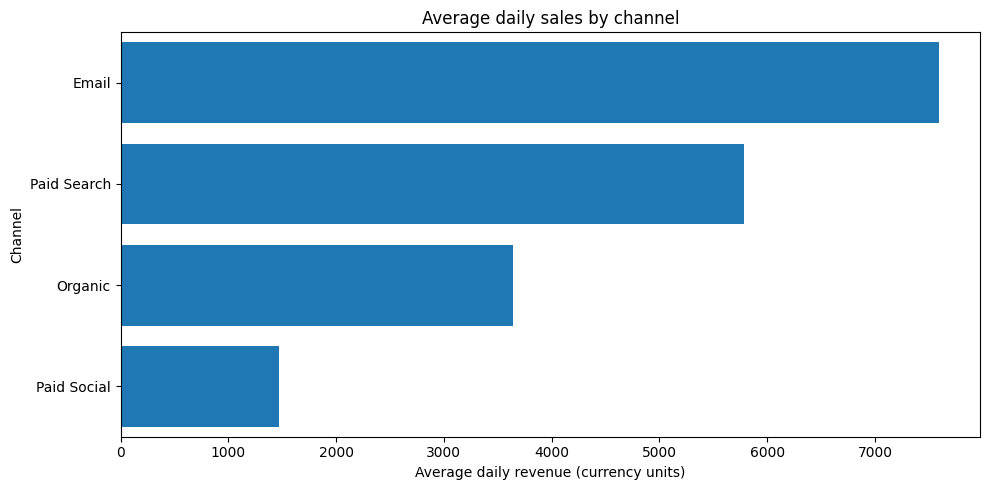

In [4]:
plt.figure(figsize=(10, 5))
plt.barh(bar_df["channel"], bar_df["revenue"])
plt.ylim(3.5, -0.5)
plt.title("Average daily sales by channel")
plt.xlabel("Average daily revenue (currency units)")
plt.ylabel("Channel")
plt.tight_layout()
plt.show()

### Polished plot: highlight the answer

Highlight Email, use the title to state the answer, and label the bar values with `plt.annotate`. Keep the revenue axis starting at zero.

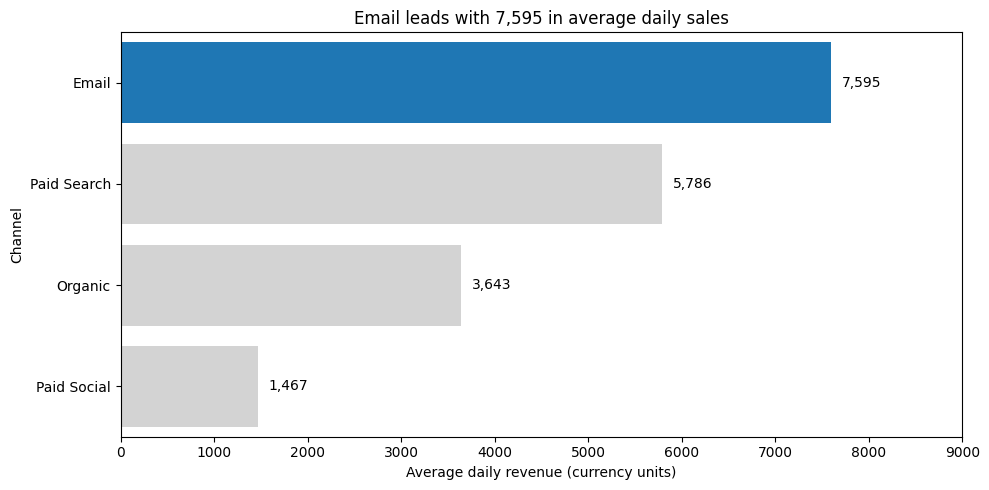

In [5]:
email_sales = float(bar_df.loc[bar_df["channel"] == "Email", "revenue"].iloc[0])

plt.figure(figsize=(10, 5))
plt.barh(bar_df["channel"], bar_df["revenue"],
         color=["tab:blue", "lightgray", "lightgray", "lightgray"])
plt.ylim(3.5, -0.5)
plt.xlim(0, 9000)
plt.title(f"Email leads with {email_sales:,.0f} in average daily sales")
plt.xlabel("Average daily revenue (currency units)")
plt.ylabel("Channel")

for channel in bar_df["channel"].tolist():
    revenue = float(bar_df.loc[bar_df["channel"] == channel, "revenue"].iloc[0])
    plt.annotate(f"{revenue:,.0f}", xy=(revenue, channel), xytext=(8, 0),
                 textcoords="offset points", va="center")

plt.tight_layout()
plt.show()

Email averages about 7,595 currency units per day, ahead of Paid Search at 5,786. The sorted positions reveal the ranking; the highlight and labels make the answer easier to find.

## 2) Line chart

**Question:** How did sales change across the four months, and which month had the highest sales?

### Data preparation

Create `line_df`. Define each month as four consecutive weeks: Month 1 covers weeks 1–4, Month 2 covers weeks 5–8, Month 3 covers weeks 9–12, and Month 4 covers weeks 13–16. Each month contains 28 days.

Use `(week - 1) // 4 + 1` to assign the month number. The `//` operator divides and keeps the whole-number part, grouping every four weeks together. Then sum revenue across all channels within each month.

In [6]:
line_df = df.copy()
line_df["month"] = (line_df["week"] - 1) // 4 + 1

line_df = (
    line_df.groupby("month", as_index=False)
           .agg(revenue=("revenue", "sum"))
)
line_df.head()

,month,revenue
0,1,481494.164121
1,2,468020.253420
2,3,563353.955539
3,4,558096.763752


### Raw plot: data exploration

Plot the four monthly totals. Each point covers the same number of days, so compare their levels and look for increases or decreases.

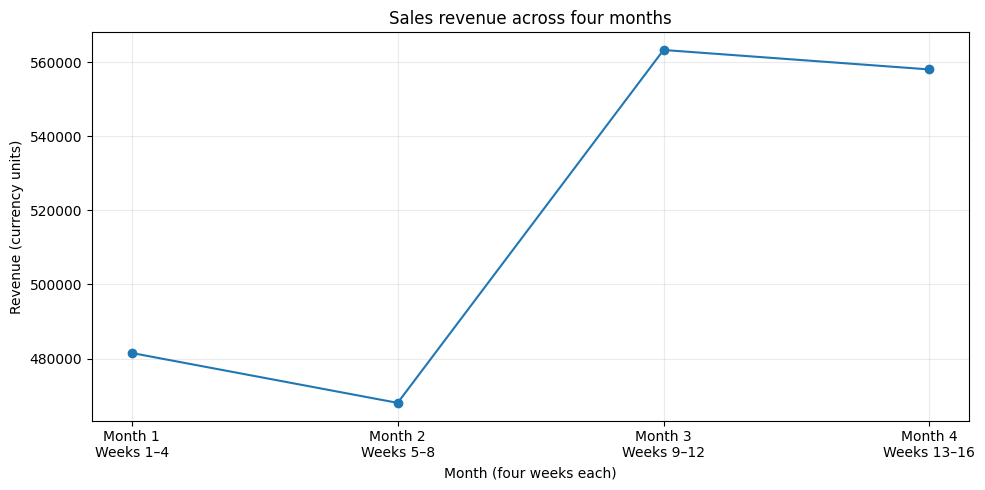

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(line_df["month"], line_df["revenue"], marker="o")
plt.title("Sales revenue across four months")
plt.xlabel("Month (four weeks each)")
plt.ylabel("Revenue (currency units)")
plt.xticks(line_df["month"], ["Month 1\nWeeks 1–4", "Month 2\nWeeks 5–8",
                             "Month 3\nWeeks 9–12", "Month 4\nWeeks 13–16"])
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Polished plot: highlight the answer

Highlight Month 3's sales and state its difference from Month 1 in the title. Keep all four months connected with a solid line because each covers a complete 28-day period.

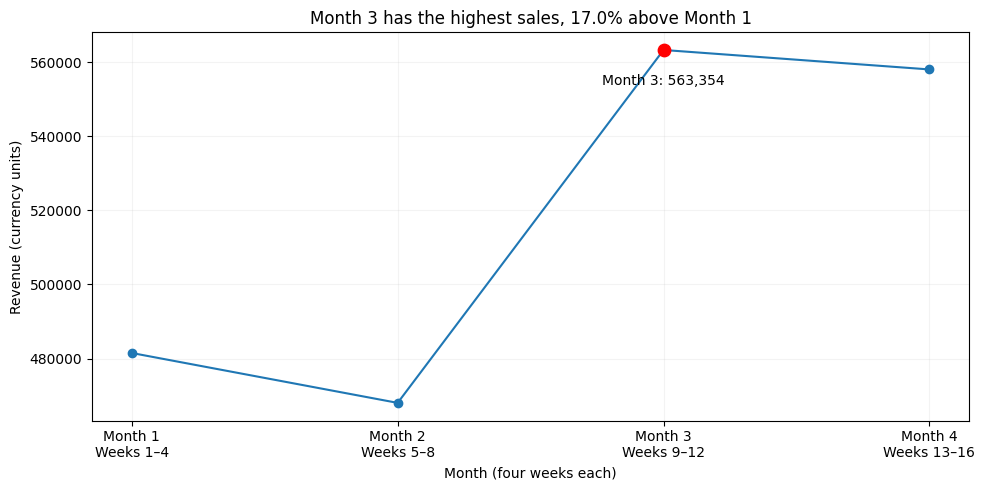

In [8]:
month1 = float(line_df.loc[line_df["month"] == 1, "revenue"].iloc[0])
month3 = float(line_df.loc[line_df["month"] == 3, "revenue"].iloc[0])
change_pct = 100 * (month3 / month1 - 1)

plt.figure(figsize=(10, 5))
plt.plot(line_df["month"], line_df["revenue"], marker="o", color="tab:blue")
plt.scatter(3, month3, color="red", s=80, zorder=3)
plt.title(f"Month 3 has the highest sales, {change_pct:.1f}% above Month 1")
plt.xlabel("Month (four weeks each)")
plt.ylabel("Revenue (currency units)")
plt.xticks(line_df["month"], ["Month 1\nWeeks 1–4", "Month 2\nWeeks 5–8",
                             "Month 3\nWeeks 9–12", "Month 4\nWeeks 13–16"])
plt.grid(True, alpha=0.15)

plt.annotate(f"Month 3: {month3:,.0f}", xy=(3, month3), xytext=(0, -25),
             textcoords="offset points", ha="center")

plt.tight_layout()
plt.show()


Sales dip from 481,494 in Month 1 to 468,020 in Month 2, then reach 563,354 in Month 3. Month 3 is 17.0% above Month 1. Month 4 records 558,097, just 0.9% below Month 3 and 15.9% above Month 1.


## 3) Scatterplot

**Question:** Do weeks with higher sales revenue also have higher profit margin rates?

### Data preparation

Create `scatter_df` by adding up revenue and margin within each week, just as in Lecture 1. Divide total margin by total revenue to calculate the margin rate. Sort by revenue so the trend line can connect points from left to right.

In [9]:
scatter_df = (
    df.groupby("week", as_index=False)
      .agg(revenue=("revenue", "sum"),
           margin=("margin", "sum"))
)

scatter_df["margin_rate"] = scatter_df["margin"] / scatter_df["revenue"]
scatter_df = scatter_df.sort_values("revenue")
scatter_df.head()

,week,revenue,margin,margin_rate
0,1,106029.244895,47195.908720,0.445122
7,8,106195.959757,46874.415542,0.441395
1,2,108569.021213,48973.752812,0.451084
5,6,115344.801469,51398.670239,0.445609
6,7,115835.442435,51726.762285,0.446554


### Raw plot: data exploration

Look for an upward or downward pattern, clusters, and unusual weeks. Each point describes one complete week.

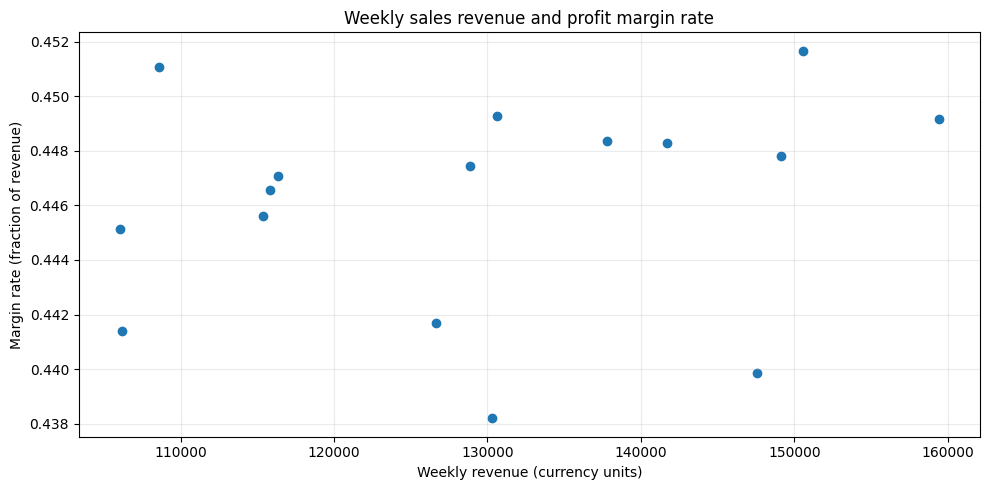

In [10]:
plt.figure(figsize=(10, 5))
plt.scatter(scatter_df["revenue"], scatter_df["margin_rate"])
plt.title("Weekly sales revenue and profit margin rate")
plt.xlabel("Weekly revenue (currency units)")
plt.ylabel("Margin rate (fraction of revenue)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Polished plot: highlight the answer

Use `np.polyfit` to fit a straight trend line. It returns a slope and an intercept: the predicted margin rate is `slope * revenue + intercept`.

The correlation coefficient, `r`, describes the strength of the linear association. Values near zero indicate a weak association. Show it in the legend and label the vertical axis as percentages.

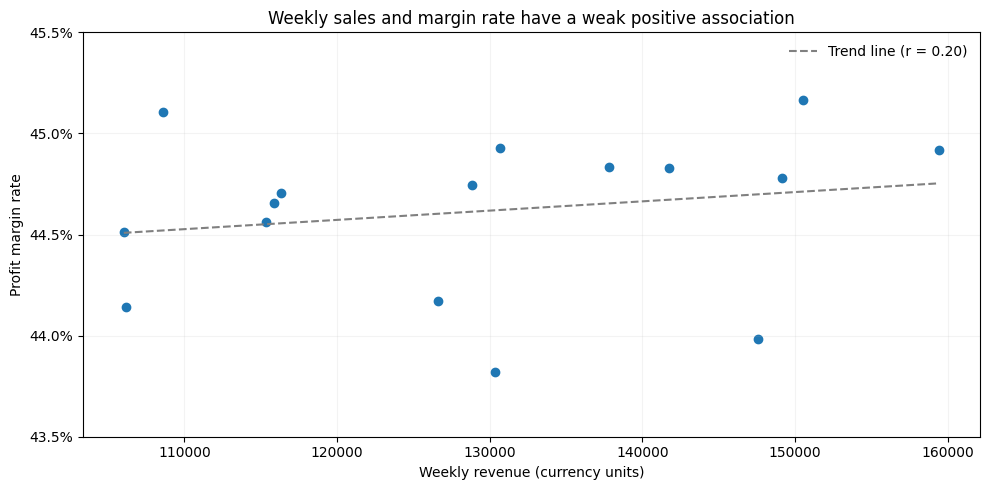

In [11]:
slope, intercept = np.polyfit(scatter_df["revenue"], scatter_df["margin_rate"], 1)
correlation = scatter_df["revenue"].corr(scatter_df["margin_rate"])

plt.figure(figsize=(10, 5))
plt.scatter(scatter_df["revenue"], scatter_df["margin_rate"], color="tab:blue")
plt.plot(scatter_df["revenue"], slope * scatter_df["revenue"] + intercept,
         color="gray", linestyle="--", label=f"Trend line (r = {correlation:.2f})")
plt.title("Weekly sales and margin rate have a weak positive association")
plt.xlabel("Weekly revenue (currency units)")
plt.ylabel("Profit margin rate")
plt.ylim(0.435, 0.455)
plt.yticks([0.435, 0.440, 0.445, 0.450, 0.455], ["43.5%", "44.0%", "44.5%", "45.0%", "45.5%"])
plt.grid(True, alpha=0.15)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

The correlation is about 0.20: higher-revenue weeks do not consistently have much higher margin rates. Observed rates range from 43.8% to 45.2%. The trend line makes the weak positive association visible without turning it into a claim that sales cause profitability to change.

## 4) Slopegraph

**Question:** Which channel has the largest difference in average daily sales between promotion and non-promotion days?

### Data preparation

Create `slope_df` with average daily revenue for each channel and promotion group. Use `pivot` to put the channels in rows and promotion status in columns: 0 means no promotion, and 1 means promotion.

Each channel has 98 non-promotion days and 14 promotion days. The endpoints compare these two groups of days, not a before-and-after sequence.

In [12]:
slope_df = (
    df.groupby(["channel", "promo"], as_index=False)
      .agg(revenue=("revenue", "mean"))
)

slope_df = slope_df.pivot(index="channel", columns="promo", values="revenue")
slope_df["difference"] = slope_df[1] - slope_df[0]
slope_df.head()

promo,0,1,difference
channel,,,
Email,7401.527812,8948.216740,1546.688929
Organic,3530.749026,4425.029814,894.280788
Paid Search,5690.245049,6456.793804,766.548755
Paid Social,1451.695972,1576.515833,124.819860


### Raw plot: data exploration

Connect each channel's two averages. Compare endpoint levels and the vertical differences between them.

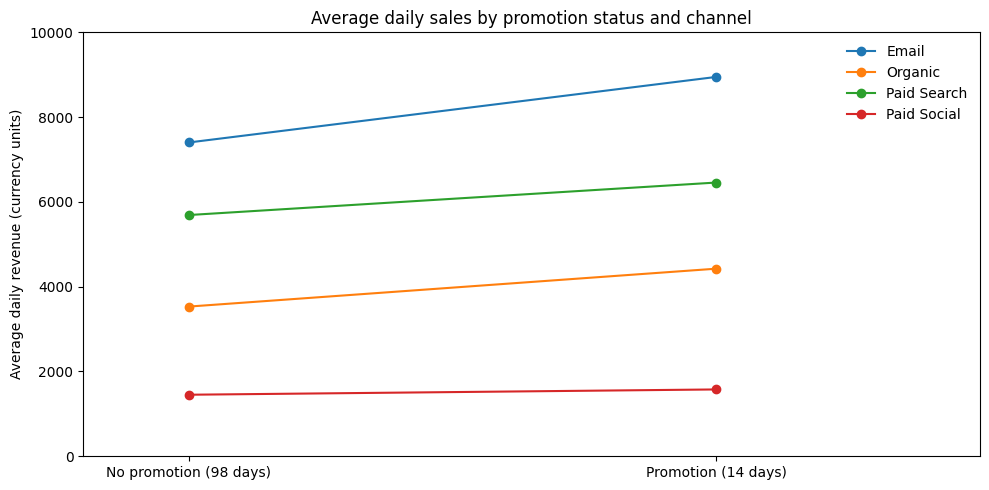

In [13]:
plt.figure(figsize=(10, 5))
for channel in slope_df.index.tolist():
    plt.plot([0, 1], [slope_df.loc[channel, 0], slope_df.loc[channel, 1]],
             marker="o", label=channel)
plt.title("Average daily sales by promotion status and channel")
plt.ylabel("Average daily revenue (currency units)")
plt.xticks([0, 1], ["No promotion (98 days)", "Promotion (14 days)"])
plt.xlim(-0.2, 1.5)
plt.ylim(0, 10000)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### Polished plot: highlight the answer

Highlight Email and label both endpoints. Use `plt.annotate`, as in Lecture 1, to show its difference in daily revenue. The other channels remain visible in gray.

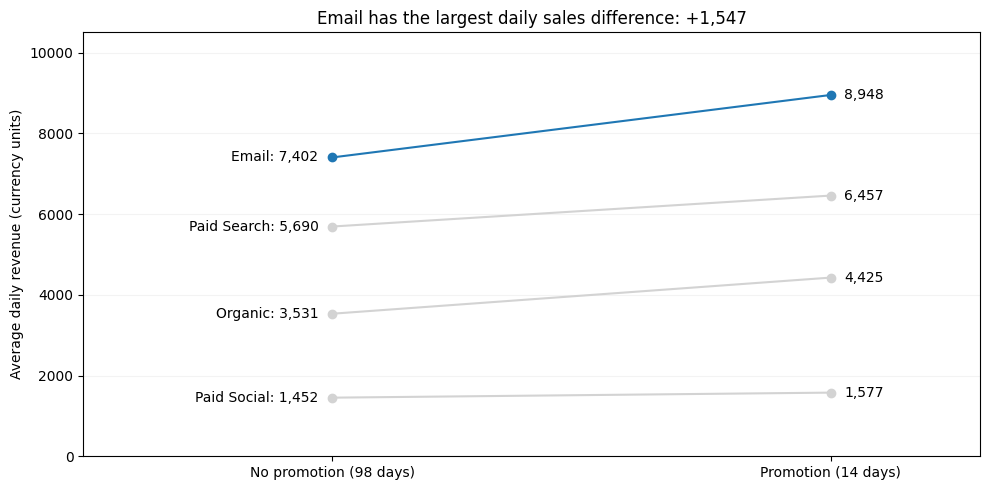

In [14]:
email_difference = slope_df.loc["Email", "difference"]

plt.figure(figsize=(10, 5))
for channel in slope_df.index.tolist():
    before = slope_df.loc[channel, 0]
    during = slope_df.loc[channel, 1]
    color = "tab:blue" if channel == "Email" else "lightgray"
    plt.plot([0, 1], [before, during], marker="o", color=color)
    plt.annotate(f"{channel}: {before:,.0f}", xy=(0, before), xytext=(-10, 0),
                 textcoords="offset points", ha="right", va="center")
    plt.annotate(f"{during:,.0f}", xy=(1, during), xytext=(10, 0),
                 textcoords="offset points", va="center")

plt.title(f"Email has the largest daily sales difference: +{email_difference:,.0f}")
plt.ylabel("Average daily revenue (currency units)")
plt.xticks([0, 1], ["No promotion (98 days)", "Promotion (14 days)"])
plt.xlim(-0.5, 1.3)
plt.ylim(0, 10500)
plt.grid(True, axis="y", alpha=0.15)
plt.tight_layout()
plt.show()

Email averages 8,948 on promotion days versus 7,402 on non-promotion days, a difference of 1,547 currency units per day. The difference uses the unrounded values. Organic has the largest percentage difference (25.3%), but Email has the largest difference in currency units.

These comparisons describe the observed days. They do not establish how much a promotion causes sales to change.

## 5) Absolute stacked bar chart

**Question:** How does total average daily revenue differ between promotion and non-promotion days, and how much does each channel contribute?

### Data preparation

Create `stacked_df` with average daily revenue for each promotion group and channel. Use `pivot` again, this time placing promotion status in rows and channels in columns. Add the four channel averages to get total average daily revenue.

Set the channel order for both plots: Email, Organic, Paid Social, Paid Search. The full bar shows the total; its segments show the breakdown.

In [15]:
stacked_df = (
    df.groupby(["promo", "channel"], as_index=False)
      .agg(revenue=("revenue", "mean"))
)

stacked_df = stacked_df.pivot(index="promo", columns="channel", values="revenue")
channels = ["Email", "Organic", "Paid Social", "Paid Search"]
colors = ["tab:blue", "darkseagreen", "plum", "goldenrod"]
stacked_df["total"] = stacked_df[channels].sum(axis=1)
stacked_df.head()

channel,Email,Organic,Paid Search,Paid Social,total
promo,,,,,
0,7401.527812,3530.749026,5690.245049,1451.695972,18074.217859
1,8948.216740,4425.029814,6456.793804,1576.515833,21406.556191


### Raw plot: data exploration

Use pandas' `.plot(kind="barh", stacked=True)` to draw horizontal stacked bars. Each column of `stacked_df[channels]` becomes one segment, in the channel order we set, and pandas places each segment where the previous one ends.

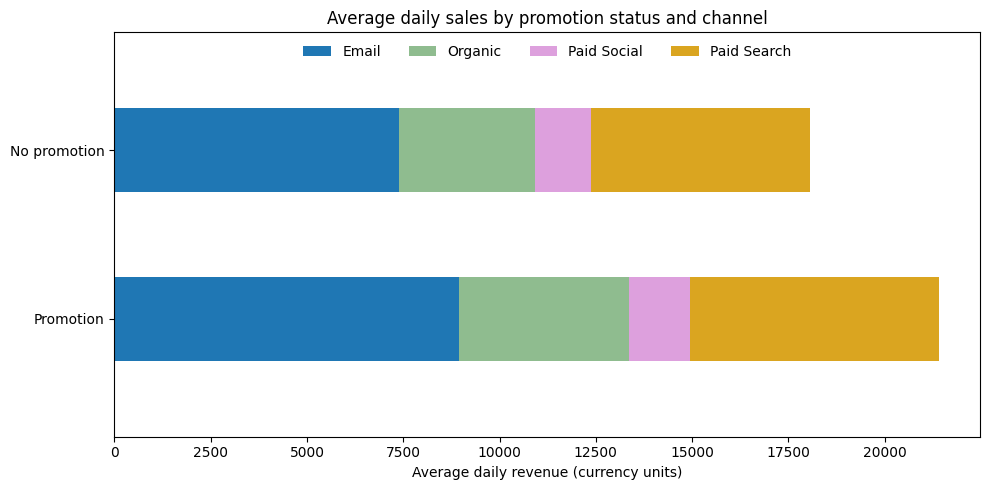

In [16]:
stacked_df[channels].plot(kind="barh", stacked=True, color=colors, figsize=(10, 5))
plt.title("Average daily sales by promotion status and channel")
plt.xlabel("Average daily revenue (currency units)")
plt.ylabel("")
plt.yticks([0, 1], ["No promotion", "Promotion"])
plt.ylim(1.7, -0.7)
plt.legend(ncol=4, frameon=False, loc="upper center")
plt.tight_layout()
plt.show()

### Polished plot: highlight the answer

State the total difference in the title. Label the channel amounts inside each bar and the total at its end. Add the number of days beside each group.

`ax.containers` holds one group of bar segments per channel. `ax.bar_label(..., label_type="center")` writes a label in the middle of each segment.

Email's segments share a zero baseline, so they are easier to compare than the middle segments. Rounded segment labels may not add exactly to the rounded total.

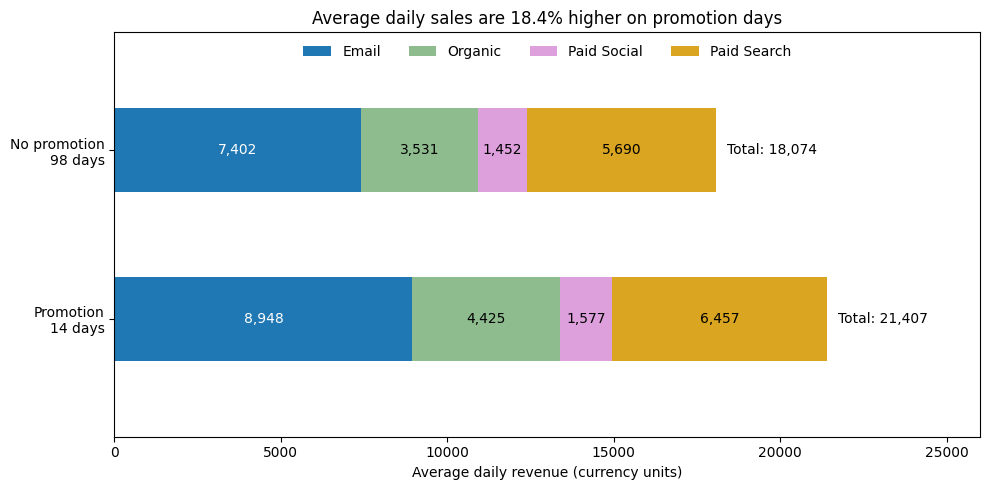

In [17]:
difference_pct = 100 * (stacked_df.loc[1, "total"] / stacked_df.loc[0, "total"] - 1)

ax = stacked_df[channels].plot(kind="barh", stacked=True, color=colors, width=0.5,
                               figsize=(10, 5))
for container, channel in zip(ax.containers, channels):
    label_color = "white" if channel == "Email" else "black"
    ax.bar_label(container, labels=[f"{revenue:,.0f}" for revenue in stacked_df[channel]],
                 label_type="center", color=label_color)

for p in [0, 1]:
    total = stacked_df.loc[p, "total"]
    plt.annotate(f"Total: {total:,.0f}", xy=(total, p), xytext=(8, 0),
                 textcoords="offset points", va="center")

plt.title(f"Average daily sales are {difference_pct:.1f}% higher on promotion days")
plt.xlabel("Average daily revenue (currency units)")
plt.ylabel("")
plt.yticks([0, 1], ["No promotion\n98 days", "Promotion\n14 days"])
plt.xlim(0, 26000)
plt.ylim(1.7, -0.7)
plt.legend(ncol=4, frameon=False, loc="upper center")
plt.tight_layout()
plt.show()

Total sales average 21,407 per promotion day versus 18,074 per non-promotion day, an 18.4% difference. Email is the largest contributor in both groups. The different dates may also differ in demand, timing, or other conditions, so this is not an estimate of a promotion's causal effect.

## 6) Proportion stacked bar chart

**Question:** How does the channel mix differ between promotion and non-promotion days, and which channel has the largest decrease in revenue share?

### Data preparation

Create `share_df` from the original data. Follow the same steps as the absolute stacked bars, then divide each channel's average daily revenue by the daily total and multiply by 100.

Each row now describes the percentage breakdown of revenue within one promotion group. Keep the daily total in a separate column so readers can still see the difference in sales volume.

In [18]:
share_df = (
    df.groupby(["promo", "channel"], as_index=False)
      .agg(revenue=("revenue", "mean"))
)

share_df = share_df.pivot(index="promo", columns="channel", values="revenue")
channels = ["Email", "Organic", "Paid Social", "Paid Search"]
colors = ["tab:blue", "darkseagreen", "plum", "goldenrod"]
share_df["total"] = share_df[channels].sum(axis=1)
for channel in channels:
    share_df[channel] = 100 * share_df[channel] / share_df["total"]
share_df.head()

channel,Email,Organic,Paid Search,Paid Social,total
promo,,,,,
0,40.950750,19.534727,31.482663,8.031861,18074.217859
1,41.801291,20.671376,30.162693,7.364640,21406.556191


### Raw plot: data exploration

Draw horizontal bars that each span 0–100%. Compare the channel mix rather than the total length.

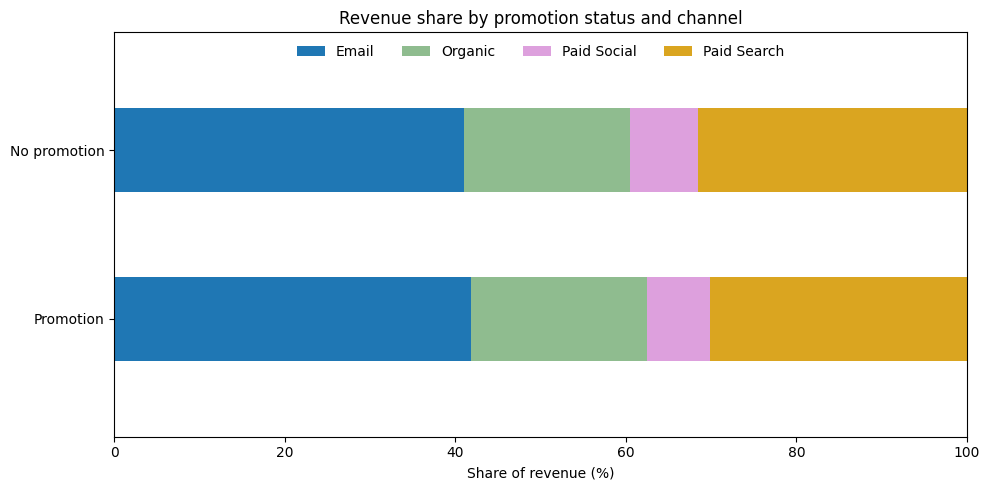

In [19]:
share_df[channels].plot(kind="barh", stacked=True, color=colors, figsize=(10, 5))
plt.title("Revenue share by promotion status and channel")
plt.xlabel("Share of revenue (%)")
plt.ylabel("")
plt.yticks([0, 1], ["No promotion", "Promotion"])
plt.xlim(0, 100)
plt.ylim(1.7, -0.7)
plt.legend(ncol=4, frameon=False, loc="upper center")
plt.tight_layout()
plt.show()

### Polished plot: highlight the answer

Label the percentages and state Paid Search's share difference in the title. Keep the daily totals beside the bars. Paid Search's segments share the right-hand 100% baseline; Email's share the left-hand zero baseline.

Use percentage points to describe a difference between shares. Rounded labels may not sum to exactly 100%.

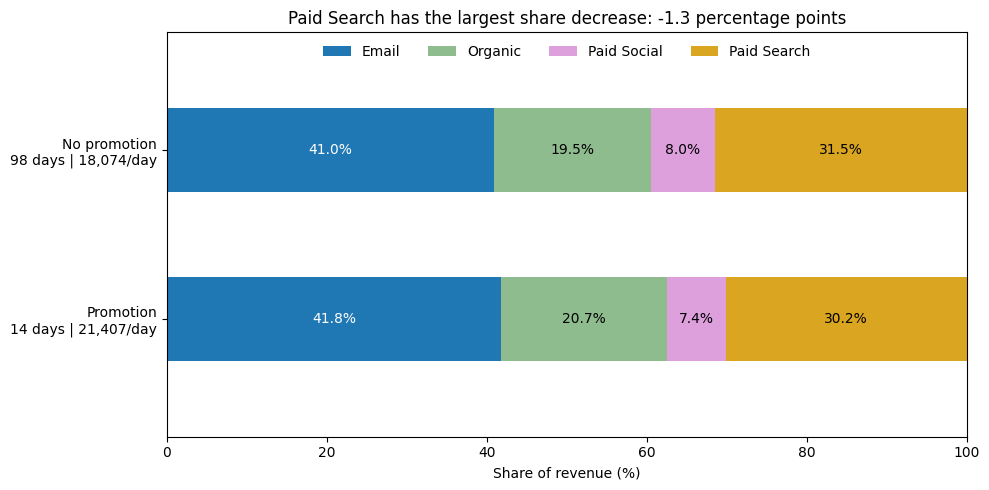

In [20]:
share_difference = share_df.loc[1, "Paid Search"] - share_df.loc[0, "Paid Search"]

ax = share_df[channels].plot(kind="barh", stacked=True, color=colors, width=0.5,
                             figsize=(10, 5))
for container, channel in zip(ax.containers, channels):
    label_color = "white" if channel == "Email" else "black"
    ax.bar_label(container, labels=[f"{share:.1f}%" for share in share_df[channel]],
                 label_type="center", color=label_color)

plt.title(f"Paid Search has the largest share decrease: {share_difference:.1f} percentage points")
plt.xlabel("Share of revenue (%)")
plt.ylabel("")
plt.yticks([0, 1], [
    f"No promotion\n98 days | {share_df.loc[0, 'total']:,.0f}/day",
    f"Promotion\n14 days | {share_df.loc[1, 'total']:,.0f}/day"
])
plt.xlim(0, 100)
plt.ylim(1.7, -0.7)
plt.legend(ncol=4, frameon=False, loc="upper center")
plt.tight_layout()
plt.show()